**Task 1**

Shape: (398, 9)
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  

Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Skewness of numeric columns:
mpg             0.457066
cylin

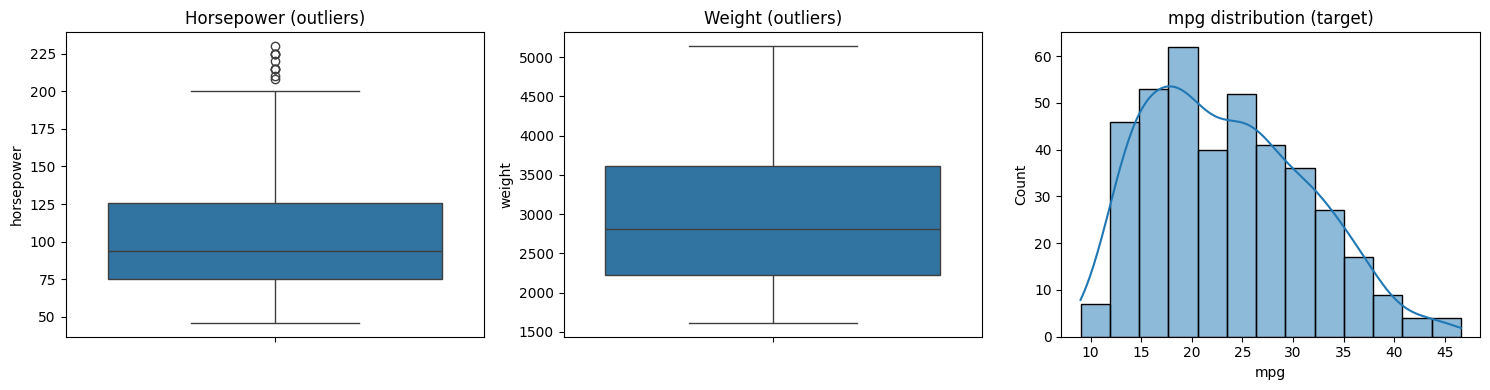


Outliers detected in horsepower: 10

Model                      MAE      RMSE        R2
Linear Regression        2.424     3.086     0.823
Ridge                    2.383     3.009     0.832
Random Forest            1.588     2.168     0.913
Gradient Boosting        1.847     2.458     0.888

Best model: Random Forest  (R2 = 0.913)


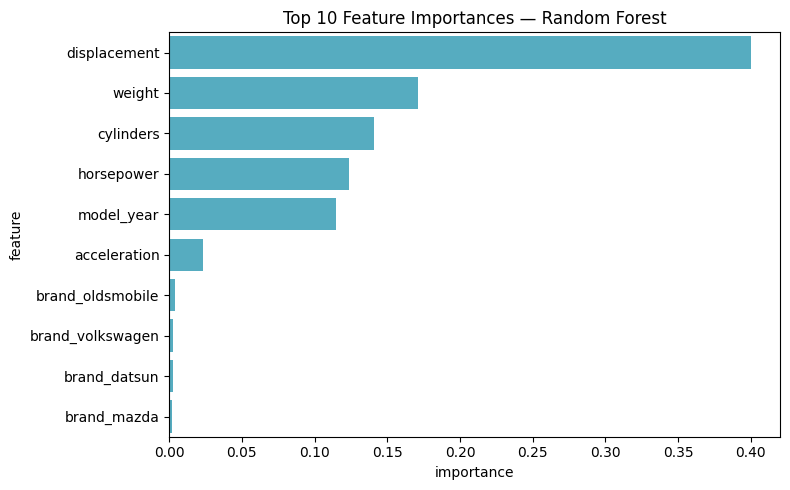

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# STEP 1: Load the data

df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv")
print("Shape:", df.shape)
print(df.head())


# STEP 2: EDA — missing values, dtypes, skew

print("\nMissing values per column:")
print(df.isnull().sum())   # horsepower has a handful of missing values

print("\nSkewness of numeric columns:")
print(df.select_dtypes(include='number').skew())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df['horsepower'], ax=axes[0]); axes[0].set_title('Horsepower (outliers)')
sns.boxplot(y=df['weight'], ax=axes[1]); axes[1].set_title('Weight (outliers)')
sns.histplot(df['mpg'], kde=True, ax=axes[2]); axes[2].set_title('mpg distribution (target)')
plt.tight_layout()
plt.show()


# STEP 3: Feature Engineering — extract car brand from name

# The 'name' column is too high-cardinality to use directly
# (almost every row is a unique string), but the BRAND is a
# genuinely useful signal, so we pull that out instead.
typo_fix = {'chevroelt': 'chevrolet', 'vokswagen': 'volkswagen', 'vw': 'volkswagen',
            'toyouta': 'toyota', 'maxda': 'mazda', 'chevy': 'chevrolet',
            'mercedes': 'mercedes-benz'}
df['brand'] = df['name'].str.split().str[0].replace(typo_fix)

# Group rare brands (fewer than 5 cars) into 'other' so OneHotEncoder
# doesn't create dozens of near-useless sparse columns
rare_brands = df['brand'].value_counts()[df['brand'].value_counts() < 5].index
df['brand'] = df['brand'].replace(rare_brands, 'other')

df = df.drop(columns=['name'])


# STEP 4: Outlier handling — cap horsepower using IQR method

Q1 = df['horsepower'].quantile(0.25)
Q3 = df['horsepower'].quantile(0.75)
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

n_outliers = ((df['horsepower'] < lower_bound) | (df['horsepower'] > upper_bound)).sum()
print(f"\nOutliers detected in horsepower: {n_outliers}")

# clip() caps values instead of deleting rows — we keep all
# 398 cars but pull extreme horsepower values back to the fence
df['horsepower'] = df['horsepower'].clip(lower_bound, upper_bound)


# STEP 5: Build preprocessing pipeline

X = df.drop(columns=['mpg'])
y = df['mpg']

numeric_features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
categorical_features = ['origin', 'brand']

# Numeric pipeline: fill missing with median, then scale.
# RobustScaler (median/IQR based) is used instead of
# StandardScaler since horsepower is right-skewed and had
# outliers we just capped — Robust handles that better.
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# STEP 6: Train multiple regression models

models_r = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results_r = {}
for name, model in models_r.items():
    # Wrapping preprocessing + model in one Pipeline means
    # fit/predict always applies the SAME transformations,
    # and there's zero risk of leaking test data into fit()
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results_r[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'pipeline': pipe}

print("\n" + "=" * 55)
print(f"{'Model':<20}{'MAE':>10}{'RMSE':>10}{'R2':>10}")
print("=" * 55)
for name, r in results_r.items():
    print(f"{name:<20}{r['MAE']:>10.3f}{r['RMSE']:>10.3f}{r['R2']:>10.3f}")

best_r_name = max(results_r, key=lambda n: results_r[n]['R2'])
print(f"\nBest model: {best_r_name}  (R2 = {results_r[best_r_name]['R2']:.3f})")


# STEP 7: Feature importance (best model, if tree-based)

best_pipe = results_r[best_r_name]['pipeline']
if hasattr(best_pipe.named_steps['model'], 'feature_importances_'):
    feat_names = (numeric_features +
                  list(best_pipe.named_steps['preprocessor']
                       .named_transformers_['cat'].named_steps['ohe']
                       .get_feature_names_out(categorical_features)))
    importances = best_pipe.named_steps['model'].feature_importances_
    imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances}) \
               .sort_values('importance', ascending=False).head(10)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=imp_df, x='importance', y='feature', color='#45B7D1')
    plt.title(f'Top 10 Feature Importances — {best_r_name}')
    plt.tight_layout()
    plt.show()

**Task 2**

Shape: (303, 14)

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Class balance:
target
0    164
1    139
Name: count, dtype: int64


/tmp/ipykernel_21215/4242054777.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=heart['target'], palette=['#4ECDC4', '#FF6B6B'])


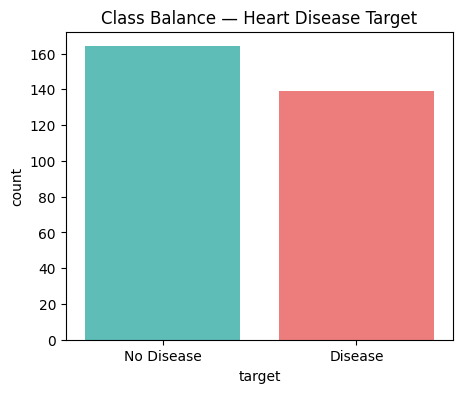


Model                   Accuracy   Precision    Recall        F1   ROC-AUC
Logistic Regression       86.89%      81.25%    92.86%    86.67%    0.9578
Random Forest             86.89%      81.25%    92.86%    86.67%    0.9416
SVM                       88.52%      81.82%    96.43%    88.52%    0.9545
KNN                       91.80%      87.10%    96.43%    91.53%    0.9562


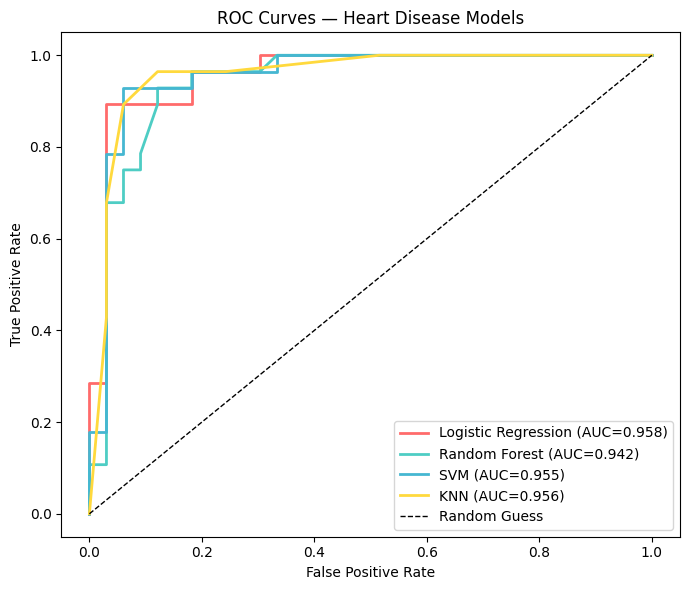


Best model: Logistic Regression  (ROC-AUC = 0.9578)


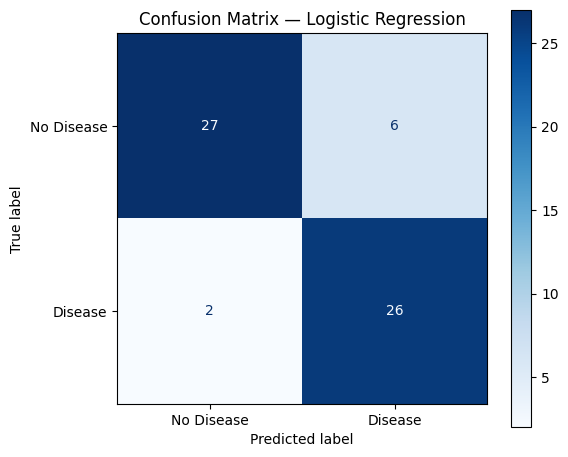

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay)


# STEP 1: Load the data — note na_values='?' which is
# exactly how missing values are marked in this dataset

column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

heart = pd.read_csv(
    "https://raw.githubusercontent.com/reinaldoq/processing-heart-disease-dataset/master/processed.cleveland.data",
    names=column_names, na_values='?'
)
print("Shape:", heart.shape)
print("\nMissing values per column:")
print(heart.isnull().sum())   # ca and thal have a few '?' entries


# STEP 2: Build the binary target

# The original 'num' column is 0 = no disease, 1-4 = increasing
# severity of disease. For this task we only care whether
# disease is present at all, so we binarize it.
heart['target'] = (heart['num'] > 0).astype(int)
heart = heart.drop(columns=['num'])

print("\nClass balance:")
print(heart['target'].value_counts())

plt.figure(figsize=(5, 4))
sns.countplot(x=heart['target'], palette=['#4ECDC4', '#FF6B6B'])
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.title('Class Balance — Heart Disease Target')
plt.show()


# STEP 3: Handle missing values

# Only 6 rows total are affected (4 in ca, 2 in thal), and both
# columns are coded categorical/ordinal values, so mode
# imputation (most frequent value) is appropriate here
heart['ca'] = heart['ca'].fillna(heart['ca'].mode()[0])
heart['thal'] = heart['thal'].fillna(heart['thal'].mode()[0])


# STEP 4: Separate columns by type

# Nominal — multi-category codes with NO inherent order,
# must be one-hot encoded
nominal_cols = ['cp', 'restecg', 'slope', 'thal']

# Binary — already 0/1, no encoding needed at all
binary_cols = ['sex', 'fbs', 'exang']

# Continuous — true numeric values that need scaling
# ('ca' is technically a count 0-3, but we treat it as
# numeric since it behaves like one)
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

X = heart.drop(columns=['target'])
y = heart['target']

numeric_pipeline = Pipeline(steps=[('scaler', StandardScaler())])
nominal_pipeline = Pipeline(steps=[('ohe', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('nom', nominal_pipeline, nominal_cols),
    ('bin', 'passthrough', binary_cols)   # binary columns pass through untouched
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


# STEP 5: Train multiple classifiers, addressing the
# (mild) class imbalance with class_weight='balanced'

models_c = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'SVM': SVC(probability=True, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=7)   # KNN has no class_weight option
}

results_c = {}
for name, model in models_c.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)

    results_c[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec,
                        'F1': f1, 'ROC-AUC': roc_auc, 'fpr': fpr, 'tpr': tpr,
                        'pipeline': pipe, 'preds': preds}

print("\n" + "=" * 70)
print(f"{'Model':<22}{'Accuracy':>10}{'Precision':>12}{'Recall':>10}{'F1':>10}{'ROC-AUC':>10}")
print("=" * 70)
for name, r in results_c.items():
    print(f"{name:<22}{r['Accuracy']*100:>9.2f}%{r['Precision']*100:>11.2f}%"
          f"{r['Recall']*100:>9.2f}%{r['F1']*100:>9.2f}%{r['ROC-AUC']:>10.4f}")


# STEP 6: ROC curves + confusion matrix for the best model

plt.figure(figsize=(7, 6))
colors_roc = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFD93D']
for (name, r), color in zip(results_c.items(), colors_roc):
    plt.plot(r['fpr'], r['tpr'], color=color, lw=2, label=f"{name} (AUC={r['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Heart Disease Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

best_c_name = max(results_c, key=lambda n: results_c[n]['ROC-AUC'])
print(f"\nBest model: {best_c_name}  (ROC-AUC = {results_c[best_c_name]['ROC-AUC']:.4f})")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, results_c[best_c_name]['preds'],
    display_labels=['No Disease', 'Disease'], cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — {best_c_name}')
plt.tight_layout()
plt.show()

In [6]:
# @title
%matplotlib inline